# ConnectaTel Customer Behavior Analysis

**Author:** Carlos Alberto Celis Martínez

## Context
As a data analyst, the goal of this project is to evaluate the behavior of customers at ConnectaTel, a telecommunications company operating in Latin America. The analysis covers data recorded through 2024 and draws on three datasets: **plans** (current plan pricing and included minutes/GB), **users** (customer demographics, registration date, plan, and churn), and **usage** (actual call and message activity).

The objective is to explore, clean, and analyze this data to build a statistical customer profile, detect atypical behaviors, and create customer segments — in order to identify consumption patterns, design retention strategies, and suggest improvements to the plans offered.

## 1. Load and Explore the Data

Import the required libraries, load the three datasets, and take a first look at their structure.

In [1]:
# import libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# load files
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv')
usage = pd.read_csv('/datasets/usage.csv')

In [3]:
# show first 5 rows of plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


## 2. Explore Dataset Structure

Review row/column counts, data types, and detect potential inconsistencies before starting the analysis.

In [6]:
# check the number of rows and columns in each dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspect plans with .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspect users with .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspect usage with .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


## 3. Data Quality Assessment

### 3.1 Missing Values

The `plans` dataset only has 2 rows and no missing values, so it needs no further exploration.

In [10]:
# count of null values for users
print(users.isna().sum())
print()
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64

user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# count of null values for usage
print(usage.isna().sum())
print()
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64

id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


**Findings — Missing values:**

The `users` dataset has 2 columns with missing data: `city` (11.7%) and `churn_date` (88.3%). The `usage` dataset has 3 columns with missing data: `date` (0.01%), `duration` (55.2%), and `length` (44.7%).

**Recommended actions:**

For `city`, I would impute with "unknown" — the proportion is high enough that dropping rows would lose a significant number of customers, and this preserves data integrity. If the analysis focused specifically on city-level behavior, dropping the unknowns could make sense instead. For `churn_date`, I would leave it as-is: the high proportion simply reflects that most customers haven't churned. I'd create a boolean `is_churn` column to flag churned customers rather than dropping the column, since it's valuable for retention analysis.

For `date` in usage, the proportion is small enough to safely drop those rows. For `duration` and `length`, these are Missing At Random (MNAR) as a direct result of the `type` column, so they should be kept as nulls.

### 3.2 Invalid Values and Sentinels

Explore numeric and categorical columns to detect sentinel values that shouldn't be in the dataset. The `plans` dataset only has 2 rows, so it needs no further exploration.

In [12]:
# explore numeric columns in users
users_numeric_cols = users[['user_id', 'age']]
users_numeric_cols.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- `user_id` has 4,000 records ranging from 10,000 to 13,999, with quartiles indicating no duplicate IDs.
- `age` has 4,000 records and a sentinel minimum of -999 that needs correcting. Quartiles and the maximum otherwise look as expected.

In [13]:
# explore numeric columns in usage
usage_numeric_cols = usage[['id', 'user_id', 'duration', 'length']]
usage_numeric_cols.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- `id` and `user_id` are identifiers linking each interaction to a user.
- `duration` and `length` show a maximum value that is notably high compared to the 75th percentile — potential outliers or data errors worth investigating further.

In [14]:
# explore categorical columns in users
user_categorical_cols = users[['city', 'plan']]
print(user_categorical_cols.describe())
print()
print('Cities')
print(users['city'].unique())
print()
print('Plans')
print(users['plan'].unique())

          city    plan
count     3531    4000
unique       7       2
top     Bogotá  Basico
freq       808    2595

Ciudades
['Medellín' '?' 'CDMX' 'Bogotá' 'GDL' 'MTY' nan 'Cali']

Planes
['Basico' 'Premium']


- `city` has 3,531 non-null values (implying missing data), 7 unique values, with Bogotá the most frequent (808 records), and a `?` placeholder value present.
- `plan` has 4,000 complete records across 2 plans, with Premium the most frequent (2,595 records).

In [15]:
# explore categorical column in usage
print(usage['type'].describe())
print()
print('Types')
print(usage['type'].unique())

count     40000
unique        2
top        text
freq      22092
Name: type, dtype: object

Types
['call' 'text']


- `type` has 40,000 complete records split across 2 categories, with `text` the most frequent (22,092 records).

**Findings — Invalid values and sentinels:**

The `age` column has a sentinel value, and `duration`/`length` show possible outliers or errors.

**Recommended actions:** Replace the `age` sentinel. For `duration` and `length`, further investigation is warranted — potentially winsorizing, or leaving them as-is.

### 3.3 Date Standardization

Convert date columns to a proper date type and check for impossible years (the dataset should only contain records through 2024).

In [16]:
# convert `reg_date` in users to datetime
users['reg_date'] = pd.to_datetime(users['reg_date'], errors='coerce')

In [17]:
# convert `date` in usage to datetime
usage['date'] = pd.to_datetime(usage['date'], errors='coerce')

In [18]:
# check years present in `reg_date` (users)
users['reg_date'].dt.year.unique()

array([2022, 2026, 2023, 2024])

`reg_date` contains an impossible year, 2026, which should be converted to NaN. Valid data exists for 2022, 2023, and 2024.

In [19]:
# check years present in `date` (usage)
usage['date'].dt.year.unique()

array([2024.,   nan])

`date` only contains records from 2024, plus the expected NaN values corresponding to the 0.01% of missing entries. The analysis will be based on this date range.

**Findings — Out-of-range dates:** `reg_date` contains the impossible year 2026 (a date that hasn't occurred yet). Since the customer record itself is valid and may reflect real service usage, this value should be converted to NaN rather than dropping the row.

## 4. Basic Data Cleaning

### 4.1 Fix Sentinels and Impossible Dates

Replace the `-999` sentinel in `age` with the median, replace the `"?"` sentinel in `city` with a null value, and mark out-of-range dates as null.

In [20]:
# replace -999 with the median of age
age_median = users['age'].median()
users['age'] = users['age'].replace(-999, pd.NA)
users['age'] = users['age'].fillna(age_median)

# verify changes
users['age'].describe()

count    4000.000000
mean       48.122250
std        17.690408
min        18.000000
25%        33.000000
50%        47.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [21]:
# replace ? with NA in city
users['city'] =  users['city'].replace('?', pd.NA)

# verify changes
users['city'].describe()

count       3435
unique         6
top       Bogotá
freq         808
Name: city, dtype: object

In [22]:
# mark future dates as NA for reg_date
users['reg_date'] =  users['reg_date'].mask(users['reg_date'].dt.year >= 2026, pd.NaT)

# verify changes
users['reg_date'].dt.year.unique()

array([2022.,   nan, 2023., 2024.])

### 4.2 Handle Remaining Missing Values

Check whether the nulls in `duration` and `length` are Missing At Random (MAR) by testing whether they depend on the `type` column. If confirmed as MAR, they're left as nulls.

In [23]:
# MAR check in usage for duration
print('Nulls in duration by type')
print(usage['duration'].isna().groupby(usage['type']).mean()*100)

Nulos en columna duration por variable type
type
call     0.000000
text    99.927576
Name: duration, dtype: float64


In [24]:
# MAR check in usage for length
print('Nulls in length by type')
usage['length'].isna().groupby(usage['type']).mean()*100

Nulos en columna length por variable type


type
call    99.932991
text     0.000000
Name: length, dtype: float64

The nulls in `length` and `duration` are a direct result of the `type` column: `duration` has 0% nulls for `type: call` versus 99% nulls for `type: text`, and the reverse pattern holds for `length` (0% nulls for `type: text`, 99% for `type: call`). This confirms they are MAR, so they are kept as nulls.

## 5. Usage Summary Statistics per User

### 5.1 Aggregating Usage Behavior

Build an aggregated table from `usage`, grouped by `user_id`, with total messages, total calls, and total call minutes, then merge it with `users`.

In [25]:
# helper columns
usage["is_text"] = (usage["type"] == "text").astype(int)  # count total messages
usage["is_call"] = (usage["type"] == "call").astype(int)  # count total calls

# group information by user
usage_agg = usage.groupby('user_id')[['is_call', 'is_text', 'duration']].sum().reset_index()

# check result
usage_agg.head(3)

,user_id,is_call,is_text,duration
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [26]:
# rename columns
usage_agg.columns = ['user_id', 'call_count', 'message_count', 'call_minutes']

# check result
usage_agg.head(3)

,user_id,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,3,7,23.70
1,10001,10,5,33.18
2,10002,2,5,10.74


In [27]:
# merge the aggregated table with the users dataset
user_profile = pd.merge(users, usage_agg, on = ['user_id'], how = 'left')
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01


### 5.2 Statistical Summary for 2024

Review numeric and categorical columns to identify ranges, extreme values, and distribution shape.

In [28]:
# statistical summary of numeric columns
numeric_cols_profile = user_profile[['age', 'call_count', 'message_count', 'call_minutes']]
print(numeric_cols_profile.describe())
print()
print('Median')
print(numeric_cols_profile.median())

               age  cant_llamadas  cant_mensajes  cant_minutos_llamada
count  4000.000000    3999.000000    3999.000000           3999.000000
mean     48.122250       4.478120       5.524381             23.317054
std      17.690408       2.144238       2.358416             18.168095
min      18.000000       0.000000       0.000000              0.000000
25%      33.000000       3.000000       4.000000             11.120000
50%      47.000000       4.000000       5.000000             19.780000
75%      63.000000       6.000000       7.000000             31.415000
max      79.000000      15.000000      17.000000            155.690000

Median
age                     47.00
cant_llamadas            4.00
cant_mensajes            5.00
cant_minutos_llamada    19.78
dtype: float64


In [29]:
# percentage distribution of plan type
print(user_profile['plan'].value_counts(normalize=True) * 100)

Basico     64.875
Premium    35.125
Name: plan, dtype: float64


## 6. Visualizing Distributions and Outliers

### 6.1 Distribution Visualization

Histograms for `age`, `message_count`, `call_count`, and `call_minutes`, comparing distributions by plan type.

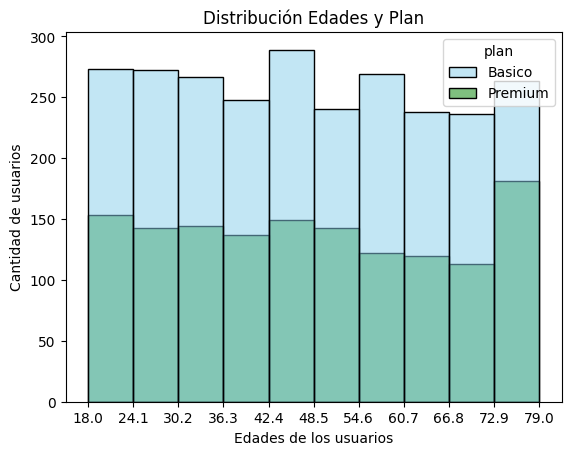

In [30]:
# histogram to visualize age
bin_edges = np.linspace(user_profile['age'].min(), user_profile['age'].max(), 11)
sns.histplot(data=user_profile, x='age', hue='plan', bins=bin_edges, palette=['skyblue','green'])

plt.xticks(bin_edges)
plt.xlabel("User age")
plt.ylabel("Number of users")
plt.title("Age Distribution by Plan")
plt.show()

In [31]:
print('Total users')
print(pd.cut(user_profile['age'], bins=bin_edges).value_counts().sort_index())

Total usuarios
(18.0, 24.1]    361
(24.1, 30.2]    415
(30.2, 36.3]    411
(36.3, 42.4]    385
(42.4, 48.5]    438
(48.5, 54.6]    383
(54.6, 60.7]    391
(60.7, 66.8]    358
(66.8, 72.9]    349
(72.9, 79.0]    444
Name: age, dtype: int64


**Insight:** Premium users show a slight downward trend as age increases. Interestingly, interest in the plan picks back up after age 73, representing the highest concentration of Premium users in the company. There's also a rise in Basic plan adoption among users aged 42–48. Despite these variations, the overall distribution is fairly uniform and flat/symmetric.

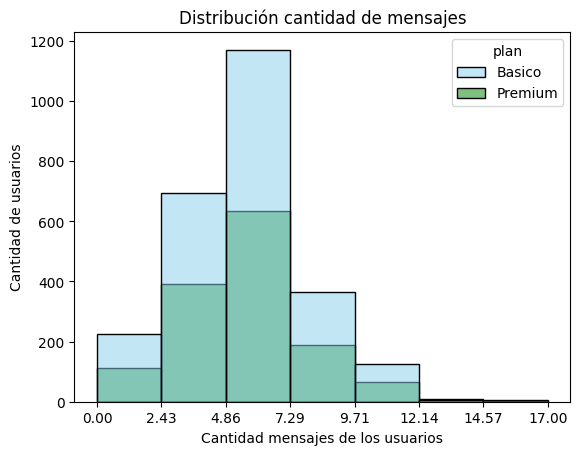

In [32]:
# histogram to visualize message_count
bin_edges = np.linspace(user_profile['message_count'].min(), user_profile['message_count'].max(), 8)
sns.histplot(data=user_profile, x='message_count', hue='plan', bins=bin_edges, palette=['skyblue','green'])

plt.xticks(bin_edges)
plt.xlabel("Number of messages")
plt.ylabel("Number of users")
plt.title("Message Count Distribution")
plt.show()

**Insight:** Plan type shows no direct correlation with message frequency — the distributions are very similar across plans. Most users fall between 5 and 7 messages. Users with more than 12 messages are extreme values. The distribution is moderately right-skewed.

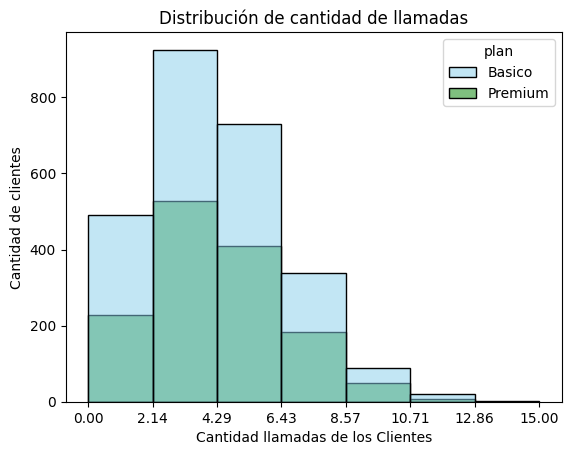

In [33]:
# histogram to visualize call_count
bin_edges = np.linspace(user_profile['call_count'].min(), user_profile['call_count'].max(), 8)
sns.histplot(data=user_profile, x='call_count', hue='plan', bins=bin_edges, palette=['skyblue','green'])

plt.xticks(bin_edges)
plt.xlabel("Number of calls")
plt.ylabel("Number of customers")
plt.title("Call Count Distribution")
plt.show()

**Insight:** Plan type again shows no direct correlation with call frequency. Most users fall between 2 and 4 calls. Users with more than 12 calls are extreme values. The distribution is right-skewed.

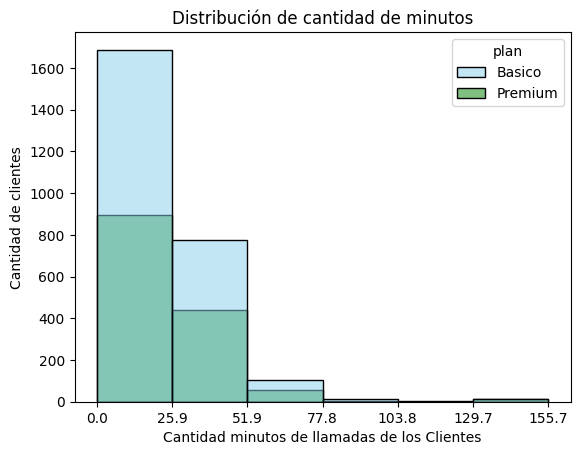

In [34]:
# histogram to visualize call_minutes
bin_edges = np.linspace(user_profile['call_minutes'].min(), user_profile['call_minutes'].max(), 7)
sns.histplot(data=user_profile, x='call_minutes', hue='plan', bins=bin_edges, palette=['skyblue','green'])

plt.xticks(bin_edges)
plt.xlabel("Total call minutes")
plt.ylabel("Number of customers")
plt.title("Call Minutes Distribution")
plt.show()

**Insight:** Plan type shows no direct correlation with total call minutes either. Most users cluster around 25 minutes. Users with more than 78 minutes are extreme values. This distribution is heavily right-skewed, with some values far from the norm.

### 6.2 Outlier Detection

Boxplots for `age`, `message_count`, `call_count`, and `call_minutes`, generated in a loop.

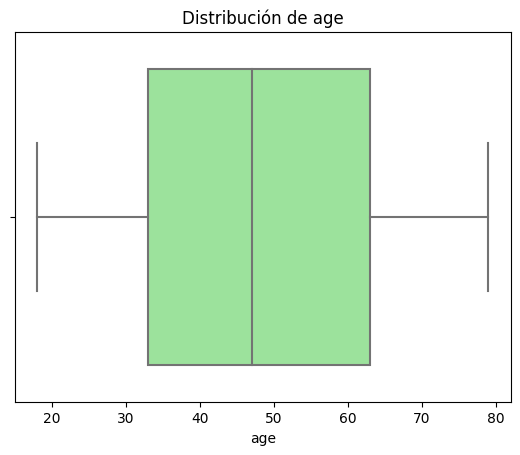

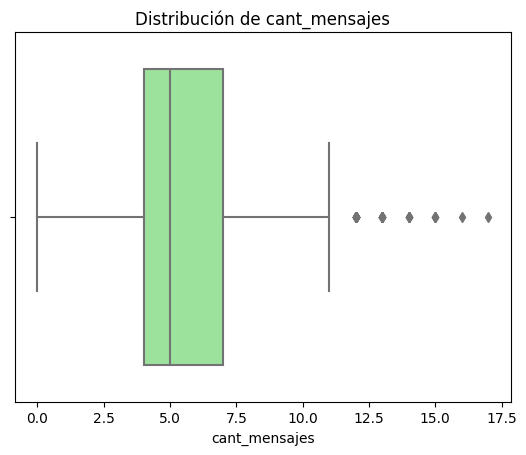

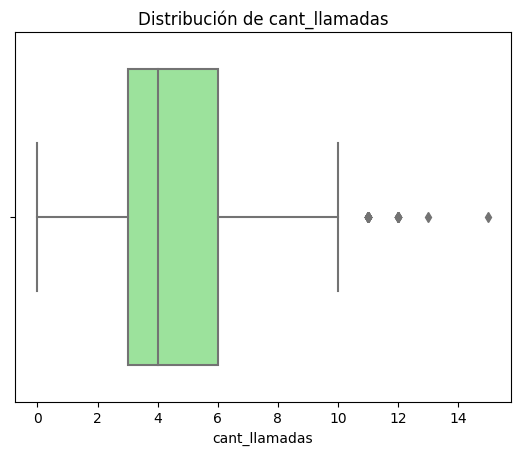

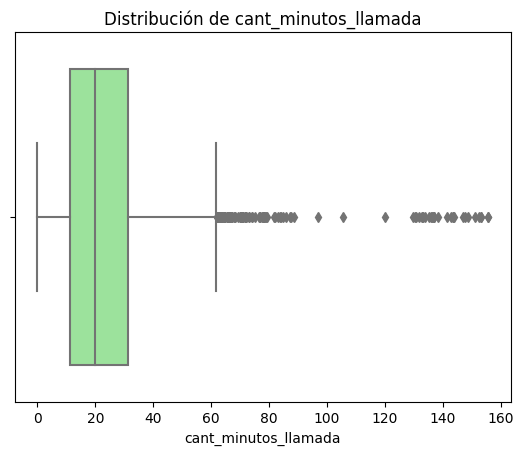

In [35]:
# visualizing with boxplots
numeric_cols = ['age', 'message_count', 'call_count', 'call_minutes']

for col in numeric_cols:
    sns.boxplot(x=user_profile[col], color='lightgreen')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.show()

**Insight:**
- `age`: no outliers present
- `message_count`: some outliers present
- `call_count`: some outliers present
- `call_minutes`: numerous outliers present

In [36]:
# calculate limits using the IQR method
outlier_cols = ['message_count', 'call_count', 'call_minutes']

for col in outlier_cols:
    q1 = user_profile[col].quantile(0.25)
    q3 = user_profile[col].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - (1.5 * iqr)
    upper_bound = q3 + (1.5 * iqr)
    print(f"Column: {col}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}\n")

Column: cant_mensajes
Límite inferior: -0.50
Límite superior: 11.50

Column: cant_llamadas
Límite inferior: -1.50
Límite superior: 10.50

Column: cant_minutos_llamada
Límite inferior: -19.32
Límite superior: 61.86



In [37]:
# review upper bounds and max values to decide whether to keep outliers
user_profile[outlier_cols].describe()

,cant_mensajes,cant_llamadas,cant_minutos_llamada
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


**Insight — decision on outliers:**

- **`message_count`:** kept — only 6 records, consistent with expected "heavy user" behavior in telecom, doesn't look like an error, and is useful for answering business questions like "which users show atypical behavior that could indicate fraud or registration errors?"
- **`call_count`:** kept — only 4 records, same reasoning as above.
- **`call_minutes`:** kept — while there are more of these, they show an expected, gradual distribution (common users ~20 min, high-usage customers 60–80 min, heavy users 130–150 min); they don't look like errors and are useful for the same fraud/anomaly business questions.

## 7. Customer Segmentation

### 7.1 Segmentation by Usage Level

Classify each user into a usage group (`Low usage`, `Medium usage`, `High usage`) based on call and message counts.

In [38]:
# create usage_group column
def classify_usage(row):
    if row['call_count'] < 5 and row['message_count'] < 5:
        return 'Low usage'
    elif row['call_count'] < 10 and row['message_count'] < 10:
        return 'Medium usage'
    else:
        return 'High usage'

user_profile['usage_group'] = user_profile.apply(classify_usage, axis=1)

In [39]:
# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,Bajo uso


### 7.2 Segmentation by Age

Classify each user into an age group (`Young`, `Adult`, `Senior`).

In [40]:
# create age_group column
def classify_age(row):
    if row['age'] < 30:
        return 'Young'
    elif row['age'] < 60:
        return 'Adult'
    else:
        return 'Senior'

user_profile['age_group'] = user_profile.apply(classify_age, axis=1)

In [41]:
# verify changes
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_llamadas,cant_mensajes,cant_minutos_llamada,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,3.0,7.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,<NA>,2022-01-01 06:34:17.914478619,Basico,NaN,10.0,5.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,2.0,5.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,3.0,11.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,3.0,4.0,8.01,Bajo uso,Adulto Mayor


### 7.3 Visualizing Customer Segments

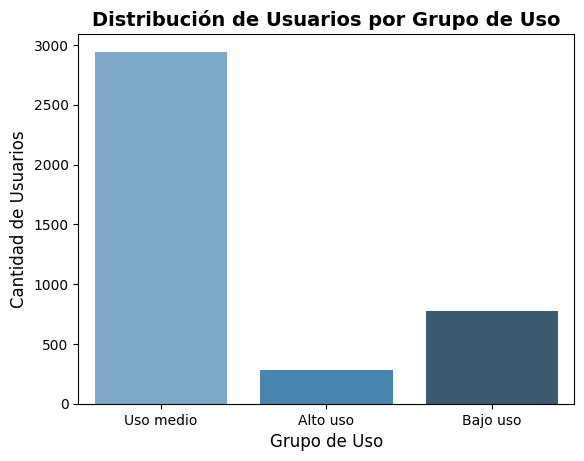

In [42]:
# visualize segments by usage
sns.countplot(data=user_profile, x="usage_group", palette="Blues_d")

plt.title("Customer Distribution by Usage Group", fontsize=14, fontweight="bold")
plt.xlabel("Usage Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()

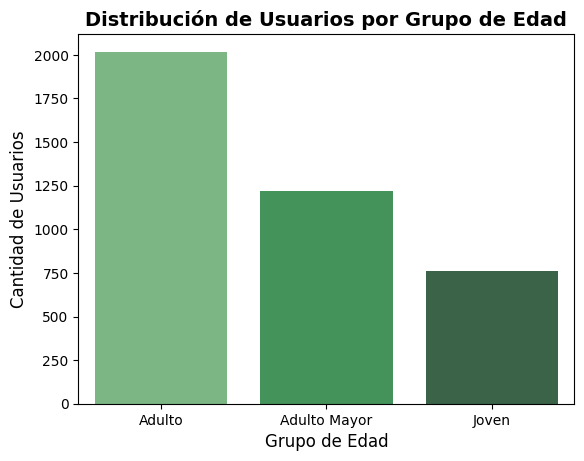

In [43]:
# visualize segments by age
sns.countplot(data=user_profile, x="age_group", palette="Greens_d")

plt.title("Customer Distribution by Age Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)

plt.show()

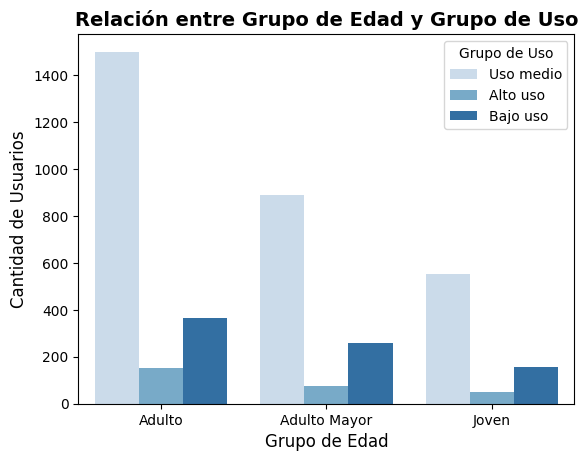

In [44]:
sns.countplot(data=user_profile, x="age_group", hue="usage_group", palette="Blues")

plt.title("Relationship Between Age Group and Usage Group", fontsize=14, fontweight="bold")
plt.xlabel("Age Group", fontsize=12)
plt.ylabel("Number of Customers", fontsize=12)
plt.legend(title="Usage Group")

plt.show()

## Executive Summary

### Data Quality Issues Identified

**Dataset: usage**
- `duration` and `length`: 55.2% and 44.7% missing, respectively — a direct result of the `type` column (MAR), so these nulls were kept.
- `date`: 0.01% missing, affecting a negligible fraction of records; not dropped. This column was originally stored as text and converted to a proper date type.

**Dataset: users**
- `churn_date`: 88.3% missing — the largest share of missing data in the users table, but this reflects the column's purpose (it only records a date for customers who have churned, rather than being a boolean flag). It doesn't compromise data integrity and is valuable for retention analysis.
- `city`: 11.7% missing (3,531 valid records out of 4,000). A `?` placeholder was found and treated as an unidentified/null value.
- `age`: Sentinel value of -999 identified and corrected. After removing this outlier, quartiles and the maximum show a normal, expected distribution.
- `reg_date`: An impossible year (2026) was found in registration records, indicating a system entry error. The valid historical range spans 2022–2024; the impossible values were corrected to NaT.

### Customer Segments by Age

The user base peaks between ages 43–48. Adults (30–60) represent the largest group overall and tend toward the Basic plan. The second-largest segment is Seniors (60+) — notably, this group shows a marked increase in Premium plan adoption after age 73. The Young segment (under 30) appears smallest, though this partly reflects a smaller underlying population in that age range rather than lower engagement; in fact, this group shows a strong presence of Premium plan users, which gradually tapers with age.

### Customer Segments by Usage Level

Segmentation by usage shows expected results: most users fall into the Medium usage group, followed by a solid Low usage group, with High usage customers representing the smallest segment. There are few outliers in message or call counts, though several outliers exist in total call minutes. No direct relationship was found between outliers and plan type or age group.

### Recommendations

1. **Shift focus beyond calls and messages.** Most customers show no friction with their message/call allowances — developing added value elsewhere (customer support, coverage, internet connectivity, etc.) could better drive interest and retention.
2. **Investigate the Young-to-Adult drop-off.** Understand what factors cause the slight decline in customers as they transition from the Young to Adult segment over time.
3. **Build loyalty with the Young segment.** Capitalize on early interest from younger customers through benefits tailored to this group, building long-term loyalty.
4. **Design targeted minute packages.** Create add-ons for high-usage customers who exceed the Basic plan's limits but aren't ready to upgrade to Premium.
5. **Target Premium marketing at Seniors.** Design campaigns aimed at this group, given the strong adoption uptick after age 70 — worth investigating what's driving that interest and giving it more visibility.